In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [8]:
X, y = load_wine(return_X_y=True)
feature_names = load_wine().feature_names
print(feature_names)
class_names = load_wine().target_names
print(class_names)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1' 'class_2']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [10]:
dt = DecisionTreeClassifier (criterion= 'entropy', max_depth=3, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

In [12]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_pred,y_test))

[[14  0  0]
 [ 0 14  0]
 [ 1  2  5]]
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       1.00      0.88      0.93        16
           2       0.62      1.00      0.77         5

    accuracy                           0.92        36
   macro avg       0.88      0.94      0.89        36
weighted avg       0.95      0.92      0.92        36



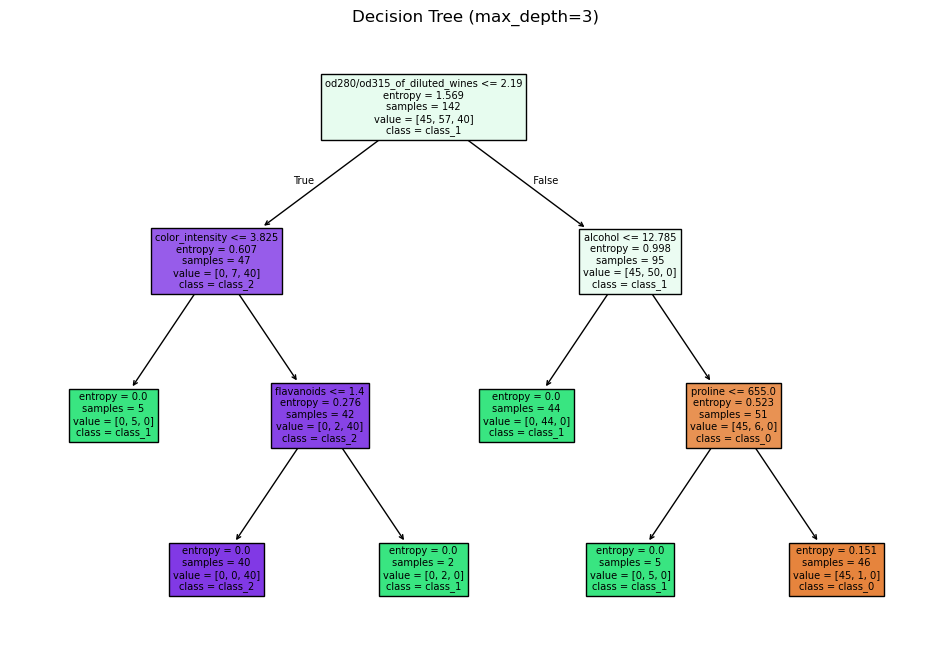

In [15]:
plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=feature_names, class_names=class_names, filled=True)
plt.title("Decision Tree (max_depth=3)")
plt.show()

In [19]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [20]:
print("\n=== Random Forest Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_rf))
print("\n=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf))


=== Random Forest Confusion Matrix ===
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [25]:
importances_dt = dt.feature_importances_
importances_rf = rf.feature_importances_

In [27]:
print("\n=== Feature Importance (Decision Tree) ===")
for name, importance in zip(feature_names, importances_dt):
    print(f"{name}: {importance:.4f}")


=== Feature Importance (Decision Tree) ===
alcohol: 0.3158
malic_acid: 0.0000
ash: 0.0000
alcalinity_of_ash: 0.0000
magnesium: 0.0000
total_phenols: 0.0000
flavanoids: 0.0537
nonflavanoid_phenols: 0.0000
proanthocyanins: 0.0000
color_intensity: 0.0785
hue: 0.0000
od280/od315_of_diluted_wines: 0.4607
proline: 0.0913
